In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

In [22]:
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [23]:
print("Starting Feature Engineering...")

# Create processed data directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

# Load the preprocessed data
train_path = '../data/processed/train_preprocessed.csv'
test_path = '../data/processed/test_preprocessed.csv'
sample_submission_path = '../data/raw/sample_submission.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print(f"Train data shape: {train.shape}")
print(f"Test data shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

# Display sample data
print("\nTrain data sample:")
print(train.head())

# Check if target variable exists
if 'Data Quality' in train.columns:
    print("\nTarget variable distribution:")
    print(train['Data Quality'].value_counts())

# Identify column types
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from lists if present
if 'Data Quality' in categorical_cols:
    categorical_cols.remove('Data Quality')
if 'Data Quality' in numerical_cols:
    numerical_cols.remove('Data Quality')

print(f"\nNumber of categorical columns: {len(categorical_cols)}")
print(f"Number of numerical columns: {len(numerical_cols)}")

Starting Feature Engineering...
Train data shape: (13998, 51)
Test data shape: (6000, 51)
Sample submission shape: (6000, 2)

Train data sample:
   Latitude  Longitude Station Code  Depth Parameter Code Data Quality  \
0    50.903     -6.649     CAN00062  0.300             OH         Fair   
1    36.339     -6.649     CAN00023  0.300             EC         Fair   
2    46.271     11.425     ITA00304  0.000             EC         Fair   
3    49.459   -120.504     CAN00328  0.300         Cs-Tot         Fair   
4    49.528   -115.549     CAN00204  0.300         Li-Tot         Good   

  Dataset_Source  temperature_avg  rainfall_mm  humidity_pct  pressure_hPa  \
0  dissolved_gas            7.008      107.991        95.000      1005.215   
1         carbon            7.008       76.765        85.981      1010.711   
2        mercury           -5.702       78.730        85.398      1008.512   
3        caesium            6.251      101.644        82.477      1008.512   
4        lithium    

In [24]:
# ==========================================
# FEATURE EXTRACTION/CREATION
# ==========================================
print("\n" + "="*50)
print("FEATURE EXTRACTION AND CREATION")
print("="*50)

# Create a copy of train and test for feature engineering
train_fe = train.copy()
test_fe = test.copy()

# 1. Transform skewed numerical features
print("\n1. Transforming skewed numerical features...")

skewed_features = ['pb_impact', 'Depth', 'hg_impact', 'ind_risk_score', 'ind_count', 'extreme_precip_days']
for feature in skewed_features:
    if feature in train_fe.columns:
        # Add small constant to handle zeros
        train_fe[f'{feature}_log'] = np.log1p(train_fe[feature])
        test_fe[f'{feature}_log'] = np.log1p(test_fe[feature])
        print(f"  - Created log-transformed feature: {feature}_log")

# 2. Create polynomial and interaction features for key environmental variables
print("\n2. Creating interaction features for environmental variables...")

# Environmental features that might interact
env_features = ['temperature_avg', 'rainfall_mm', 'humidity_pct', 'pressure_hPa', 'drought_index']

# Create interactions between environmental features
for i, feat1 in enumerate(env_features):
    for feat2 in env_features[i+1:]:
        if feat1 in train_fe.columns and feat2 in train_fe.columns:
            # Interaction (multiplication)
            train_fe[f'{feat1}_{feat2}_interact'] = train_fe[feat1] * train_fe[feat2]
            test_fe[f'{feat1}_{feat2}_interact'] = test_fe[feat1] * test_fe[feat2]
            print(f"  - Created interaction feature: {feat1}_{feat2}_interact")

# 3. Create ratio features for land use variables
print("\n3. Creating ratio features for land use variables...")

land_use_cols = [col for col in train_fe.columns if col.endswith('_pct')]
if len(land_use_cols) > 0:
    # Calculate urban to natural ratio (urban / (forest + wetland + grassland))
    if all(col in train_fe.columns for col in ['urban_pct', 'forest_pct', 'wetland_pct', 'grassland_pct']):
        train_fe['urban_to_natural_ratio'] = train_fe['urban_pct'] / (train_fe['forest_pct'] + train_fe['wetland_pct'] + train_fe['grassland_pct'] + 1e-5)
        test_fe['urban_to_natural_ratio'] = test_fe['urban_pct'] / (test_fe['forest_pct'] + test_fe['wetland_pct'] + test_fe['grassland_pct'] + 1e-5)
        print("  - Created urban_to_natural_ratio")
    
    # Calculate water availability ratio (water + wetland) / (urban + barren)
    if all(col in train_fe.columns for col in ['water_pct', 'wetland_pct', 'urban_pct', 'barren_pct']):
        train_fe['water_availability_ratio'] = (train_fe['water_pct'] + train_fe['wetland_pct']) / (train_fe['urban_pct'] + train_fe['barren_pct'] + 1e-5)
        test_fe['water_availability_ratio'] = (test_fe['water_pct'] + test_fe['wetland_pct']) / (test_fe['urban_pct'] + test_fe['barren_pct'] + 1e-5)
        print("  - Created water_availability_ratio")
    
    # Calculate agricultural intensity (agriculture / forest)
    if all(col in train_fe.columns for col in ['agriculture_pct', 'forest_pct']):
        train_fe['agricultural_intensity'] = train_fe['agriculture_pct'] / (train_fe['forest_pct'] + 1e-5)
        test_fe['agricultural_intensity'] = test_fe['agriculture_pct'] / (test_fe['forest_pct'] + 1e-5)
        print("  - Created agricultural_intensity")

# 4. Create features from temporal data
print("\n4. Creating features from temporal data...")

# Check if temporal components are already extracted during preprocessing
if 'date' in train_fe.columns and 'date' not in ['year', 'month', 'day', 'season']:
    train_fe['date'] = pd.to_datetime(train_fe['date'])
    test_fe['date'] = pd.to_datetime(test_fe['date'])
    
    # Extract year, month, day if not already present
    if 'year' not in train_fe.columns:
        train_fe['year'] = train_fe['date'].dt.year
        test_fe['year'] = test_fe['date'].dt.year
        print("  - Extracted year from date")
    
    if 'month' not in train_fe.columns:
        train_fe['month'] = train_fe['date'].dt.month
        test_fe['month'] = test_fe['date'].dt.month
        print("  - Extracted month from date")
    
    if 'day' not in train_fe.columns:
        train_fe['day'] = train_fe['date'].dt.day
        test_fe['day'] = test_fe['date'].dt.day
        print("  - Extracted day from date")

# Create cyclical features for month (to capture seasonality)
if 'month' in train_fe.columns:
    train_fe['month_sin'] = np.sin(2 * np.pi * train_fe['month']/12)
    train_fe['month_cos'] = np.cos(2 * np.pi * train_fe['month']/12)
    test_fe['month_sin'] = np.sin(2 * np.pi * test_fe['month']/12)
    test_fe['month_cos'] = np.cos(2 * np.pi * test_fe['month']/12)
    print("  - Created cyclical month features: month_sin, month_cos")

# 5. Create risk score composite
print("\n5. Creating composite risk score...")

if all(col in train_fe.columns for col in ['ind_risk_score', 'hg_impact', 'pb_impact']):
    # Normalize and combine risk factors
    train_fe['composite_risk_score'] = train_fe['ind_risk_score'] + train_fe['hg_impact'] + train_fe['pb_impact']
    test_fe['composite_risk_score'] = test_fe['ind_risk_score'] + test_fe['hg_impact'] + test_fe['pb_impact']
    print("  - Created composite_risk_score")


FEATURE EXTRACTION AND CREATION

1. Transforming skewed numerical features...
  - Created log-transformed feature: pb_impact_log
  - Created log-transformed feature: Depth_log
  - Created log-transformed feature: hg_impact_log
  - Created log-transformed feature: ind_risk_score_log
  - Created log-transformed feature: ind_count_log
  - Created log-transformed feature: extreme_precip_days_log

2. Creating interaction features for environmental variables...
  - Created interaction feature: temperature_avg_rainfall_mm_interact
  - Created interaction feature: temperature_avg_humidity_pct_interact
  - Created interaction feature: temperature_avg_pressure_hPa_interact
  - Created interaction feature: temperature_avg_drought_index_interact
  - Created interaction feature: rainfall_mm_humidity_pct_interact
  - Created interaction feature: rainfall_mm_pressure_hPa_interact
  - Created interaction feature: rainfall_mm_drought_index_interact
  - Created interaction feature: humidity_pct_pressur

In [25]:
# 6. Create binary flags from categorical variables
print("\n6. Creating binary flags from categorical variables...")

# Create binary flags for important categorical variables
binary_flag_cols = [
    ('is_referenced_method', 'True'), 
    ('validated_results', 'True'),
    ('sampling_weather', 'Clear')
]

for col, value in binary_flag_cols:
    if col in train_fe.columns:
        flag_name = f'flag_{col}_{value}'
        train_fe[flag_name] = (train_fe[col] == value).astype(int)
        test_fe[flag_name] = (test_fe[col] == value).astype(int)
        print(f"  - Created binary flag: {flag_name}")

# 7. Create parameter type indicators
print("\n7. Creating parameter type indicators...")

if 'param_category' in train_fe.columns:
    param_categories = train_fe['param_category'].unique()
    for category in param_categories:
        flag_name = f'param_is_{category.lower().replace(" ", "_")}'
        train_fe[flag_name] = (train_fe['param_category'] == category).astype(int)
        test_fe[flag_name] = (test_fe['param_category'] == category).astype(int)
        print(f"  - Created parameter category flag: {flag_name}")

# 8. Create geographic region features
print("\n8. Creating geographic region features...")

if 'Latitude' in train_fe.columns and 'Longitude' in train_fe.columns:
    # Create hemisphere flags
    train_fe['northern_hemisphere'] = (train_fe['Latitude'] >= 0).astype(int)
    test_fe['northern_hemisphere'] = (test_fe['Latitude'] >= 0).astype(int)
    print("  - Created northern_hemisphere flag")
    
    train_fe['eastern_hemisphere'] = (train_fe['Longitude'] >= 0).astype(int)
    test_fe['eastern_hemisphere'] = (test_fe['Longitude'] >= 0).astype(int)
    print("  - Created eastern_hemisphere flag")
    
    # Create distance from equator
    train_fe['distance_from_equator'] = np.abs(train_fe['Latitude'])
    test_fe['distance_from_equator'] = np.abs(test_fe['Latitude'])
    print("  - Created distance_from_equator")

# 9. Create proxy for industry proximity
if 'ind_count' in train_fe.columns and 'distance_from_equator' in train_fe.columns:
    # Create a simple industry proximity score
    train_fe['industry_proximity'] = train_fe['ind_count'] / (train_fe['distance_from_equator'] + 1)
    test_fe['industry_proximity'] = test_fe['ind_count'] / (test_fe['distance_from_equator'] + 1)
    print("  - Created industry_proximity score")

# 10. Create temperature range feature based on season
print("\n10. Creating temperature range features...")

if 'temperature_avg' in train_fe.columns and 'season' in train_fe.columns:
    # Calculate average temperature by season
    season_temp_avg = train_fe.groupby('season')['temperature_avg'].mean()
    
    # Calculate temperature deviation from seasonal average
    for season in season_temp_avg.index:
        season_avg = season_temp_avg[season]
        mask_train = train_fe['season'] == season
        mask_test = test_fe['season'] == season
        
        train_fe.loc[mask_train, 'temp_season_diff'] = train_fe.loc[mask_train, 'temperature_avg'] - season_avg
        test_fe.loc[mask_test, 'temp_season_diff'] = test_fe.loc[mask_test, 'temperature_avg'] - season_avg
    
    print("  - Created temp_season_diff (deviation from seasonal average)")

# 11. Create feature for water quality concern level
print("\n11. Creating water quality concern indicator...")

if all(col in train_fe.columns for col in ['pb_impact', 'hg_impact', 'ind_risk_score']):
    # Combine metal impacts with risk score to create water quality concern indicator
    train_fe['water_quality_concern'] = (
        (train_fe['pb_impact'] > 0).astype(int) + 
        (train_fe['hg_impact'] > 0).astype(int) + 
        (train_fe['ind_risk_score'] > 0).astype(int)
    )
    test_fe['water_quality_concern'] = (
        (test_fe['pb_impact'] > 0).astype(int) + 
        (test_fe['hg_impact'] > 0).astype(int) + 
        (test_fe['ind_risk_score'] > 0).astype(int)
    )
    print("  - Created water_quality_concern indicator")


6. Creating binary flags from categorical variables...
  - Created binary flag: flag_is_referenced_method_True
  - Created binary flag: flag_validated_results_True
  - Created binary flag: flag_sampling_weather_Clear

7. Creating parameter type indicators...
  - Created parameter category flag: param_is_other
  - Created parameter category flag: param_is_heavy_metal
  - Created parameter category flag: param_is_common_ion
  - Created parameter category flag: param_is_metal
  - Created parameter category flag: param_is_nutrient

8. Creating geographic region features...
  - Created northern_hemisphere flag
  - Created eastern_hemisphere flag
  - Created distance_from_equator
  - Created industry_proximity score

10. Creating temperature range features...
  - Created temp_season_diff (deviation from seasonal average)

11. Creating water quality concern indicator...
  - Created water_quality_concern indicator


In [26]:
# ==========================================
# FEATURE ENCODING
# ==========================================
print("\n" + "="*50)
print("FEATURE ENCODING")
print("="*50)

# 1. Handle categorical variables
print("\n1. Encoding categorical variables...")

# Determine which categorical variables to one-hot encode (low cardinality) and which to label encode (high cardinality)
cat_cols_for_onehot = []
cat_cols_for_label = []

for col in categorical_cols:
    if col in train_fe.columns:
        unique_count = train_fe[col].nunique()
        if unique_count < 10:  # Low cardinality
            cat_cols_for_onehot.append(col)
        else:  # High cardinality
            cat_cols_for_label.append(col)

print(f"  - Categorical columns for one-hot encoding ({len(cat_cols_for_onehot)}): {cat_cols_for_onehot}")
print(f"  - Categorical columns for label encoding ({len(cat_cols_for_label)}): {cat_cols_for_label}")

# Apply one-hot encoding for low cardinality variables
train_test_combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

for col in cat_cols_for_onehot:
    if col in train_fe.columns:
        # Get dummies
        dummies = pd.get_dummies(train_test_combined[col], prefix=col, drop_first=True)
        
        # Add encoded columns to train and test
        for dummy_col in dummies.columns:
            train_fe[dummy_col] = dummies.iloc[:len(train_fe)][dummy_col].values
            test_fe[dummy_col] = dummies.iloc[len(train_fe):][dummy_col].values
        
        # Drop original column
        train_fe = train_fe.drop(col, axis=1)
        test_fe = test_fe.drop(col, axis=1)
        print(f"  - One-hot encoded: {col} -> {len(dummies.columns)} features")

# Apply mean encoding for high cardinality variables (alternative to target encoding)
if 'Data Quality' in train.columns:
    for col in cat_cols_for_label:
        if col in train_fe.columns:
            # Create a mapping of categories to their target mean
            target_means = train_fe.groupby(col)['Data Quality'].apply(
                lambda x: (x == 'Good').mean()
            ).to_dict()
            
            # Apply the mapping
            train_fe[f'{col}_mean_enc'] = train_fe[col].map(target_means)
            test_fe[f'{col}_mean_enc'] = test_fe[col].map(target_means)
            
            # Handle unseen categories in test set
            mean_enc_mean = train_fe[f'{col}_mean_enc'].mean()
            test_fe[f'{col}_mean_enc'] = test_fe[f'{col}_mean_enc'].fillna(mean_enc_mean)
            
            # Drop original column
            train_fe = train_fe.drop(col, axis=1)
            test_fe = test_fe.drop(col, axis=1)
            print(f"  - Mean encoded: {col} -> {col}_mean_enc")
else:
    print("  - Mean encoding skipped (no target variable found)")
    # Use label encoding for high cardinality variables when target is not available
    for col in cat_cols_for_label:
        if col in train_fe.columns:
            # Initialize label encoder
            encoder = LabelEncoder()
            
            # Fit on combined data to ensure all categories are captured
            encoder.fit(train_test_combined[col].astype(str).fillna('Unknown'))
            
            # Transform train and test data
            train_fe[f'{col}_label_enc'] = encoder.transform(train_fe[col].astype(str).fillna('Unknown'))
            test_fe[f'{col}_label_enc'] = encoder.transform(test_fe[col].astype(str).fillna('Unknown'))
            
            # Drop original column
            train_fe = train_fe.drop(col, axis=1)
            test_fe = test_fe.drop(col, axis=1)
            print(f"  - Label encoded: {col} -> {col}_label_enc")

# 2. Drop columns that are no longer needed
print("\n2. Dropping unnecessary columns...")

# Columns to drop
cols_to_drop = [
    'date',  # already extracted year, month, day
    'time_season',  # already extracted season
    'value_with_unit',  # already extracted value and unit
]

# Drop columns if they exist
for col in cols_to_drop:
    if col in train_fe.columns:
        train_fe = train_fe.drop(col, axis=1)
        test_fe = test_fe.drop(col, axis=1)
        print(f"  - Dropped column: {col}")


FEATURE ENCODING

1. Encoding categorical variables...
  - Categorical columns for one-hot encoding (8): ['param_category', 'sampling_method', 'water_body_type', 'pollution_risk', 'sampling_weather', 'regulatory_framework', 'land_use_impact', 'season']
  - Categorical columns for label encoding (10): ['Station Code', 'Parameter Code', 'Dataset_Source', 'country_code', 'time_season', 'value_with_unit', 'analytical_program', 'testing_laboratory', 'date', 'unit']
  - One-hot encoded: param_category -> 4 features
  - One-hot encoded: sampling_method -> 4 features
  - One-hot encoded: water_body_type -> 7 features
  - One-hot encoded: pollution_risk -> 3 features
  - One-hot encoded: sampling_weather -> 5 features
  - One-hot encoded: regulatory_framework -> 8 features
  - One-hot encoded: land_use_impact -> 3 features
  - One-hot encoded: season -> 3 features
  - Mean encoded: Station Code -> Station Code_mean_enc
  - Mean encoded: Parameter Code -> Parameter Code_mean_enc
  - Mean encode


FEATURE SELECTION

Number of features after engineering: 61

1. Analyzing correlations between features...
  - Found 24 highly correlated feature pairs (r > 0.9)
    * time_season_mean_enc & date_mean_enc: 1.0000
    * drought_index & pressure_hPa_drought_index_interact: 1.0000
    * temperature_avg & temperature_avg_pressure_hPa_interact: 1.0000
    * rainfall_mm & rainfall_mm_pressure_hPa_interact: 1.0000
    * humidity_pct & humidity_pct_pressure_hPa_interact: 0.9997
    * drought_index & humidity_pct_drought_index_interact: 0.9947
    * humidity_pct_drought_index_interact & pressure_hPa_drought_index_interact: 0.9947
    * temperature_avg & temperature_avg_humidity_pct_interact: 0.9917
    * temperature_avg_humidity_pct_interact & temperature_avg_pressure_hPa_interact: 0.9917
    * urban_pct & urban_to_natural_ratio: 0.9791

2. Removing redundant features based on correlation...
  - Dropped redundant feature: humidity_pct_pressure_hPa_interact
  - Dropped redundant feature: humidi

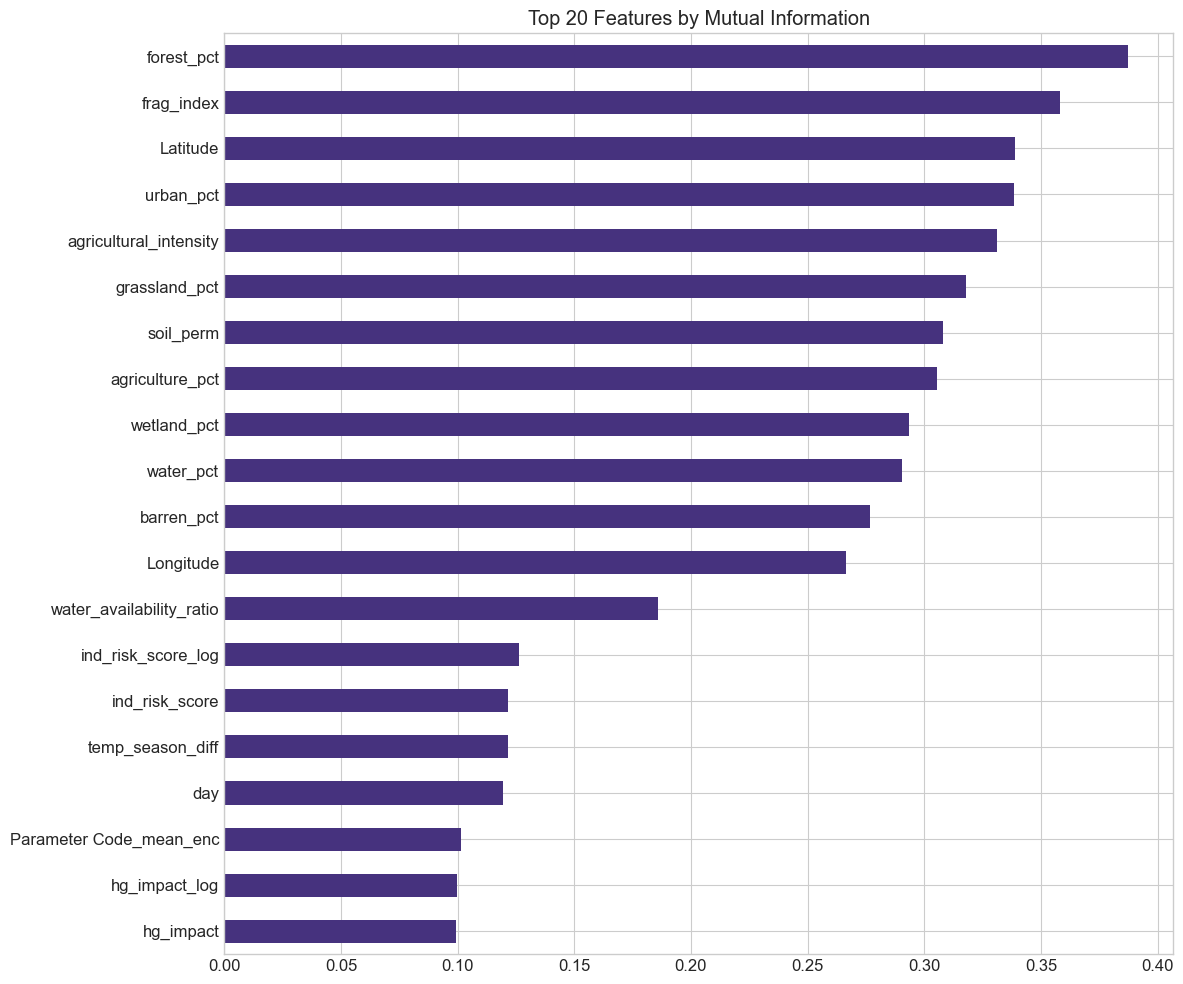


Selected 45 features based on mutual information


In [27]:
# ==========================================
# FEATURE SELECTION
# ==========================================
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)

# Identify numerical features after encoding
numerical_cols_fe = train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Data Quality' in numerical_cols_fe:
    numerical_cols_fe.remove('Data Quality')
if 'id' in numerical_cols_fe:
    numerical_cols_fe.remove('id')

print(f"\nNumber of features after engineering: {len(numerical_cols_fe)}")

# 1. Correlation Analysis
print("\n1. Analyzing correlations between features...")

# Calculate correlation matrix
correlation_matrix = train_fe[numerical_cols_fe].corr().abs()

# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.9:  # Correlation threshold
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, corr))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
print(f"  - Found {len(high_corr_pairs)} highly correlated feature pairs (r > 0.9)")

# Print top highly correlated pairs
for i, (col1, col2, corr) in enumerate(high_corr_pairs[:10]):
    print(f"    * {col1} & {col2}: {corr:.4f}")

# 2. Identify and remove redundant features
print("\n2. Removing redundant features based on correlation...")

# Columns to remove due to high correlation
to_drop = set()
for col1, col2, _ in high_corr_pairs:
    # Keep one of the two correlated features (simple heuristic: keep the one with shorter name)
    if len(col1) > len(col2):
        to_drop.add(col1)
    else:
        to_drop.add(col2)

# Drop redundant features
for col in to_drop:
    if col in train_fe.columns:
        train_fe = train_fe.drop(col, axis=1)
        test_fe = test_fe.drop(col, axis=1)
        print(f"  - Dropped redundant feature: {col}")

# 3. Feature importance analysis
if 'Data Quality' in train.columns:
    print("\n3. Analyzing feature importance using mutual information...")
    # Prepare target for feature importance analysis
    y = train['Data Quality']
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Select numerical features for importance analysis
    X = train_fe.select_dtypes(include=['int64', 'float64'])
    
    # Calculate mutual information scores
    mi_scores = mutual_info_classif(X, y_encoded, random_state=42)
    mi_scores = pd.Series(mi_scores, index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    
    # Print top important features
    print("\nTop 15 features by mutual information:")
    for i, (feature, score) in enumerate(mi_scores.head(15).items()):
        print(f"  {i+1}. {feature}: {score:.6f}")
    
    # Visualize feature importance
    plt.figure(figsize=(12, 10))
    mi_scores.head(20).sort_values().plot(kind='barh')
    plt.title('Top 20 Features by Mutual Information')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png')
    plt.show()
    
    # Select top features based on mutual information
    n_select = min(100, len(X.columns))  # Select top 100 features or all if less than 100
    selector = SelectKBest(mutual_info_classif, k=n_select)
    selector.fit(X, y_encoded)
    
    # Get selected feature names
    selected_features = X.columns[selector.get_support()]
    print(f"\nSelected {len(selected_features)} features based on mutual information")
    
    # Make sure we keep these selected features and the target
    keep_columns = list(selected_features)
    if 'Data Quality' not in keep_columns and 'Data Quality' in train_fe.columns:
        keep_columns.append('Data Quality')
    
    # Keep only selected features plus any non-numeric columns we want to retain
    non_numeric_to_keep = ['id'] if 'id' in train_fe.columns else []
    keep_columns = keep_columns + non_numeric_to_keep
    
    # Filter columns in train and test
    train_fe = train_fe[keep_columns]
    test_cols = [col for col in keep_columns if col in test_fe.columns]
    test_fe = test_fe[test_cols]
else:
    print("  - Feature importance analysis skipped (no target variable found)")


In [28]:
# ==========================================
# FEATURE SCALING
# ==========================================
print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Identify numerical features after selection
numerical_cols_final = train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Data Quality' in numerical_cols_final:
    numerical_cols_final.remove('Data Quality')
if 'id' in numerical_cols_final:
    numerical_cols_final.remove('id')

print(f"\nNumber of numerical features for scaling: {len(numerical_cols_final)}")

# Apply standard scaling
scaler = StandardScaler()
train_fe[numerical_cols_final] = scaler.fit_transform(train_fe[numerical_cols_final])
test_fe[numerical_cols_final] = scaler.transform(test_fe[numerical_cols_final])
print("  - Applied StandardScaler to all numerical features")



FEATURE SCALING

Number of numerical features for scaling: 45
  - Applied StandardScaler to all numerical features


In [29]:
# ==========================================
# SAVE ENGINEERED FEATURES
# ==========================================
print("\n" + "="*50)
print("SAVING ENGINEERED FEATURES")
print("="*50)

# Final data shapes
print(f"\nFinal train data shape: {train_fe.shape}")
print(f"Final test data shape: {test_fe.shape}")

# Save engineered datasets
train_fe.to_csv('../data/processed/train_engineered.csv', index=False)
test_fe.to_csv('../data/processed/test_engineered.csv', index=False)

print("\nEngineered features saved to:")
print(f"  - ../data/processed/train_engineered.csv")
print(f"  - ../data/processed/test_engineered.csv")


SAVING ENGINEERED FEATURES

Final train data shape: (13998, 46)
Final test data shape: (6000, 45)

Engineered features saved to:
  - ../data/processed/train_engineered.csv
  - ../data/processed/test_engineered.csv


In [30]:
# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*50)
print("FEATURE ENGINEERING SUMMARY")
print("="*50)

print("\n1. Feature Extraction/Creation:")
print(f"  - Transformed {len(skewed_features)} skewed numerical features")
print(f"  - Created interaction features between environmental variables")
print(f"  - Created ratio features for land use variables")
print(f"  - Created temporal features including cyclical month encoding")
print(f"  - Created composite risk score")
print(f"  - Created binary flags from categorical variables")
print(f"  - Created geographic region features")

print("\n2. Feature Encoding:")
print(f"  - One-hot encoded {len(cat_cols_for_onehot)} categorical variables")
print(f"  - Label/Mean encoded {len(cat_cols_for_label)} high-cardinality categorical variables")

print("\n3. Feature Selection:")
print(f"  - Removed {len(to_drop)} redundant features based on correlation analysis")
if 'Data Quality' in train.columns:
    print(f"  - Selected {len(selected_features)} features based on mutual information with target")

print("\n4. Feature Scaling:")
print(f"  - Applied standard scaling to {len(numerical_cols_final)} numerical features")

print("\nFeature engineering complete! Data is now ready for modeling.")


FEATURE ENGINEERING SUMMARY

1. Feature Extraction/Creation:
  - Transformed 6 skewed numerical features
  - Created interaction features between environmental variables
  - Created ratio features for land use variables
  - Created temporal features including cyclical month encoding
  - Created composite risk score
  - Created binary flags from categorical variables
  - Created geographic region features

2. Feature Encoding:
  - One-hot encoded 8 categorical variables
  - Label/Mean encoded 10 high-cardinality categorical variables

3. Feature Selection:
  - Removed 16 redundant features based on correlation analysis
  - Selected 45 features based on mutual information with target

4. Feature Scaling:
  - Applied standard scaling to 45 numerical features

Feature engineering complete! Data is now ready for modeling.
